# Calculations for the bottom 500 m 

In this notebook, we compute all necessarily diagnostics for the analysis of the seasonal and inter-annual variability of the passive tracers: 
- Monthly climatology 
- Seasonal range 
- Seasonal phase (peak month of tracer concentration)
- Standard deviation
- Coefficient of variation



In [1]:
import xarray as xr
import numpy as np
import sys
import intake
import dask.distributed as dask
import matplotlib.pyplot as plt 
import xrft
# import cmcrameri

import sys
sys.path.append("/g/data/x77/ps7863/python_scripts/AABW_variability/")
import helper_funcs as helper

In [2]:
client = dask.Client(threads_per_worker = 1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45775 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/45775/status,
Dashboard: /proxy/45775/status,Workers: 24
Total threads: 24,Total memory: 95.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34535,Workers: 0
Dashboard: /proxy/45775/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41877,Total threads: 1
Dashboard: /proxy/34707/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:34853,


In [3]:
figdir = '/g/data/x77/ps7863/figures/AABW_variability/bottom_500m/'
savedir = '/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/'
iaf_cycle3 = '01deg_jra55v140_iaf_cycle3'
catalog = intake.cat.access_nri

In [4]:
# lon_slice = slice(80-360, 190-360)
lat_slice = slice(-82, -55)

degree =  u'\N{DEGREE SIGN}'

In [5]:
first_year = 1968
last_year = 2018
start_time = f'01-01-{first_year}'
end_time = f'31-12-{last_year}'
time_slice = slice(start_time, end_time)

In [6]:
# albw = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/ALBW_tracer_bottom_500_1958-2018.nc')
# rsbw = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/RSBW_tracer_bottom_500_merged_1958-2018.nc')
# wsbw = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/WSBW_tracer_bottom_500_1958-2018.nc')
# pbbw = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/PBBW_tracer_bottom_500_1958-2018.nc')
# albw = albw['ALBW_tracer']
# rsbw = rsbw['RSBW tracer']
# wsbw = wsbw['WSBW tracer']
# pbbw = pbbw['PBBW tracer']

# albw = albw.sel(time=time_slice)
# rsbw = rsbw.sel(time=time_slice)

wsbw = xr.open_dataset(f'{savedir}/WSBW_tracer_bottom_500m_01deg_jra55v140_iaf_cycle3_1958-2018.nc')
rsbw = xr.open_dataset(f'{savedir}/RSBW_tracer_bottom_500m_01deg_jra55v140_iaf_cycle3_1958-2018.nc')
albw = xr.open_dataset(f'{savedir}/ALBW_tracer_bottom_500m_01deg_jra55v140_iaf_cycle3_1958-2018.nc')
pbbw = xr.open_dataset(f'{savedir}/PBBW_tracer_bottom_500m_01deg_jra55v140_iaf_cycle3_1958-2018.nc')
wsbw = wsbw['passive_weddell']
rsbw = rsbw['passive_ross']
albw = albw['passive_adelie']
pbbw = pbbw['passive_prydz']

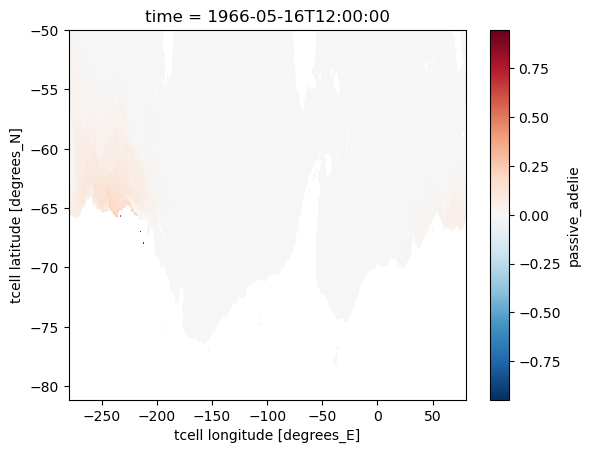

In [7]:
albw.isel(time=100).plot()

In [8]:
# These chunks are good for circumpolar data. If regionally sliced - don't use  
chunks_dict = {
    'xt_ocean': 360, 
    'yt_ocean': 584, 
    'time': 72
}
albw = albw.chunk(chunks_dict)
wsbw = wsbw.chunk(chunks_dict)
rsbw = rsbw.chunk(chunks_dict)
pbbw = pbbw.chunk(chunks_dict)

In [9]:
rsbw = rsbw.sel(time=time_slice)
albw = albw.sel(time=time_slice)
wsbw = wsbw.sel(time=time_slice)
pbbw = pbbw.sel(time=time_slice)

In [10]:
where_nan = np.isnan(albw.isel(time=0))
albw = albw.where(~where_nan,0)
where_nan = np.isnan(rsbw.isel(time=0))
rsbw = rsbw.where(~where_nan,0)
where_nan = np.isnan(pbbw.isel(time=0))
pbbw = pbbw.where(~where_nan,0)
where_nan = np.isnan(wsbw.isel(time=0))
wsbw = wsbw.where(~where_nan,0)

In [11]:
def detrend_keep_mean(da, dim="time"):
    """
    Remove only the linear slope a*t, keep the intercept (mean level).
    Works lazily with Dask and preserves original time coordinate.
    """
    # 1) Build relative time in years since the first timestep
    t = da[dim]
    t0 = t.isel({dim: 0})
    # convert to days first (allowed), then to years
    t_rel_years = ((t - t0) / np.timedelta64(1, "D")) / 365.2425
    t_rel_years = xr.DataArray(t_rel_years, dims=t.dims, coords={dim: t})

    # 2) Fit a linear model using the relative-time coordinate
    da_rel = da.assign_coords({dim: t_rel_years})
    fit = da_rel.polyfit(dim=dim, deg=1, skipna=True)
    a = fit.polyfit_coefficients.sel(degree=1)              # slope (per year)

    # 3) Subtract only the slope term a*t (keep mean/intercept)
    #    Make sure 'a' broadcasts over da
    a = a.broadcast_like(da)
    da_detr = da - a * t_rel_years

    return da_detr


In [12]:
rsbw_detr = detrend_keep_mean(rsbw)  # rsbw has a 'time' dim
albw_detr = detrend_keep_mean(albw)
wsbw_detr = detrend_keep_mean(wsbw)
pbbw_detr = detrend_keep_mean(pbbw)

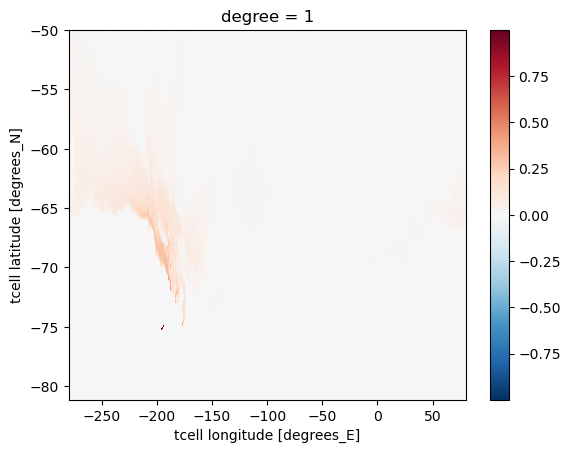

In [21]:
rsbw_detr.mean('time').plot()

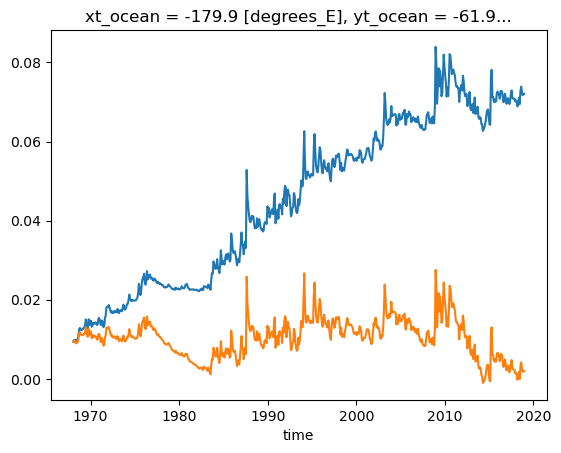

In [12]:
rsbw.isel(xt_ocean=1000, yt_ocean=450).plot()
rsbw_detr.isel(xt_ocean=1000, yt_ocean=450).plot()

## Mean tracer

In [13]:
def annual_mean_from_monthly(var):
    month_length = var.time.dt.days_in_month
    total_days = month_length.sum('time')
    weighted_var = var * month_length / total_days
    weighted_mean = weighted_var.sum('time')
    return weighted_mean 


In [14]:
rsbw_mean = annual_mean_from_monthly(rsbw)
albw_mean = annual_mean_from_monthly(albw)
wsbw_mean = annual_mean_from_monthly(wsbw)
pbbw_mean = annual_mean_from_monthly(pbbw)

In [32]:
rsbw_mean_ds = rsbw_mean.to_dataset(name='RSBW mean concentration').assign_attrs(description='Mean concentration of Ross tracer (1968–2018)')
albw_mean_ds = albw_mean.to_dataset(name='ALBW mean concentration').assign_attrs(description='Mean concentration of Adélie tracer (1968–2018)')
wsbw_mean_ds = wsbw_mean.to_dataset(name='WSBW mean concentration').assign_attrs(description='Mean concentration of Weddell tracer (1968–2018)')
pbbw_mean_ds = pbbw_mean.to_dataset(name='PBBW mean concentration').assign_attrs(description='Mean concentration of Prydz tracer (1968–2018)')

rsbw_mean_ds.to_netcdf(f'{savedir}/rsbw_circumpolar_mean_{first_year}-{last_year}.nc')
albw_mean_ds.to_netcdf(f'{savedir}/albw_circumpolar_mean_{first_year}-{last_year}.nc')
pbbw_mean_ds.to_netcdf(f'{savedir}/pbbw_circumpolar_mean_{first_year}-{last_year}.nc')
wsbw_mean_ds.to_netcdf(f'{savedir}/wsbw_circumpolar_mean_{first_year}-{last_year}.nc')

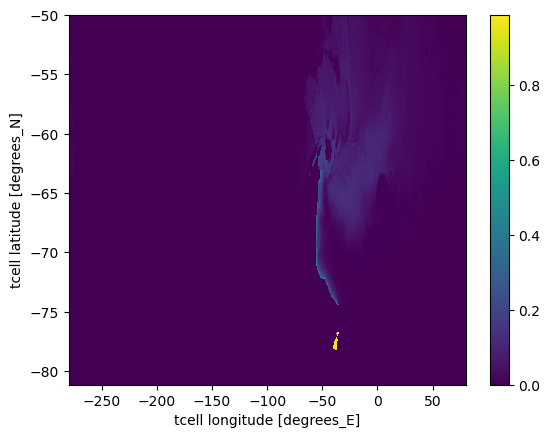

In [17]:
wsbw_mean.plot()

In [16]:
rsbw_mean_detr = annual_mean_from_monthly(rsbw_detr)
albw_mean_detr = annual_mean_from_monthly(albw_detr)
wsbw_mean_detr = annual_mean_from_monthly(wsbw_detr)
pbbw_mean_detr = annual_mean_from_monthly(pbbw_detr)

In [14]:
rsbw_mean_ds = rsbw_mean_detr.to_dataset(name='RSBW mean concentration').assign_attrs(description='Mean concentration of detrended Ross tracer (1968–2018)')
albw_mean_ds = albw_mean_detr.to_dataset(name='ALBW mean concentration').assign_attrs(description='Mean concentration of detrended Adélie tracer (1968–2018)')
wsbw_mean_ds = wsbw_mean_detr.to_dataset(name='WSBW mean concentration').assign_attrs(description='Mean concentration of detrended Weddell tracer (1968–2018)')
pbbw_mean_ds = pbbw_mean_detr.to_dataset(name='PBBW mean concentration').assign_attrs(description='Mean concentration of detrended Prydz tracer (1968–2018)')

rsbw_mean_ds.to_netcdf(f'{savedir}/rsbw_circumpolar_detrended_mean_{first_year}-{last_year}.nc')
albw_mean_ds.to_netcdf(f'{savedir}/albw_circumpolar_detrended_mean_{first_year}-{last_year}.nc')
# pbbw_mean_ds.to_netcdf(f'{savedir}/pbbw_circumpolar_detrended_mean_{first_year}-{last_year}.nc')
# wsbw_mean_ds.to_netcdf(f'{savedir}/wsbw_circumpolar_detrended_mean_{first_year}-{last_year}.nc')

2025-12-16 14:16:20,741 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.42 GiB -- Worker memory limit: 3.96 GiB
2025-12-16 14:16:39,979 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.41 GiB -- Worker memory limit: 3.96 GiB


## Monthly climatology

In [17]:
def groupby_weighted_mean(da, group, w):
    num = (da * w).groupby(group).sum('time')
    den = w.groupby(group).sum('time')
    return num / den

In [18]:
w = xr.DataArray(albw.sel(time=time_slice)['time'].dt.days_in_month,
                 coords={'time': albw.sel(time=time_slice)['time']}, dims='time')
albw_clim_weighted = groupby_weighted_mean(albw_detr, 'time.month', w)
rsbw_clim_weighted = groupby_weighted_mean(rsbw_detr, 'time.month', w)
wsbw_clim_weighted = groupby_weighted_mean(wsbw_detr, 'time.month', w)
pbbw_clim_weighted = groupby_weighted_mean(pbbw_detr, 'time.month', w)

In [60]:

# albw_clim = albw_detr.groupby('time.month').mean('time')
# rsbw_clim = rsbw_detr.groupby('time.month').mean('time')
# wsbw_clim = wsbw_detr.groupby('time.month').mean('time')
# pbbw_clim = pbbw_detr.groupby('time.month').mean('time')

In [61]:
# where_nan = np.isnan(albw_clim.sel(month=1))
# albw_clim = albw_clim.where(~where_nan,0)
# where_nan = np.isnan(rsbw_clim.sel(month=1))
# rsbw_clim = rsbw_clim.where(~where_nan,0)
# where_nan = np.isnan(pbbw_clim.sel(month=1))
# pbbw_clim = pbbw_clim.where(~where_nan,0)
# where_nan = np.isnan(wsbw_clim.sel(month=1))
# wsbw_clim = wsbw_clim.where(~where_nan,0)

In [34]:
albw_clim_weighted.to_dataset(name='ALBW_clim').assign_attrs(description='Monthly climatology of Adélie tracer (weighted)').to_netcdf(f'{savedir}/ALBW_climatology_detrended_1968-2018.nc')
rsbw_clim_weighted.to_dataset(name='RSBW_clim').assign_attrs(description='Monthly climatology of Ross tracer (weighted)').to_netcdf(f'{savedir}/RSBW_climatology_detrended_1968-2018.nc')
wsbw_clim_weighted.to_dataset(name='WSBW_clim').assign_attrs(description='Monthly climatology of Weddell tracer (weighted)').to_netcdf(f'{savedir}/WSBW_climatology_detrended_1968-2018.nc')
pbbw_clim_weighted.to_dataset(name='PBBW_clim').assign_attrs(description='Monthly climatology of Prydz tracer (weighted)').to_netcdf(f'{savedir}/PBBW_climatology_detrended_1968-2018.nc')

    

2025-12-19 12:17:14,346 - distributed.worker.memory - WARNING - Worker is at 82% memory usage. Pausing worker.  Process memory: 3.26 GiB -- Worker memory limit: 3.96 GiB
2025-12-19 12:17:15,402 - distributed.worker.memory - WARNING - Worker is at 59% memory usage. Resuming worker. Process memory: 2.34 GiB -- Worker memory limit: 3.96 GiB
2025-12-19 12:17:16,406 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.59 GiB -- Worker memory limit: 3.96 GiB
2025-12-19 12:17:16,462 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memo

## Seasonal range 

In [19]:
albw_range = albw_clim_weighted.max('month') - albw_clim_weighted.min('month')
rsbw_range = rsbw_clim_weighted.max('month') - rsbw_clim_weighted.min('month')
wsbw_range = wsbw_clim_weighted.max('month') - wsbw_clim_weighted.min('month')
pbbw_range = pbbw_clim_weighted.max('month') - pbbw_clim_weighted.min('month')

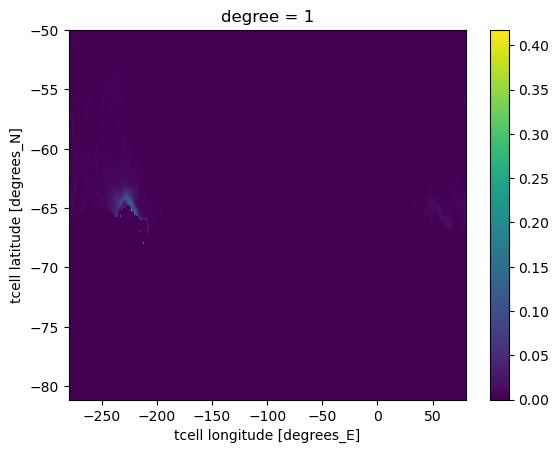

In [22]:
albw_range.plot()

In [36]:
albw_range.to_dataset(name='ALBW_range').assign_attrs(description='Seasonal range of detrended Adélie tracer (1968-2018').to_netcdf(f'{savedir}/ALBW_range_detrended_{first_year}-{last_year}.nc')
# rsbw_range.to_dataset(name='RSBW_range').assign_attrs(description='Seasonal range of detrended Ross tracer (1968-2018').to_netcdf(f'{savedir}/RSBW_range_detrended_{first_year}-{last_year}.nc')
# wsbw_range.to_dataset(name='WSBW_range').assign_attrs(description='Seasonal range of detrended Weddell tracer (1968-2018').to_netcdf(f'{savedir}/WSBW_range_detrended_{first_year}-{last_year}.nc')
# pbbw_range.to_dataset(name='PBBW_range').assign_attrs(description='Seasonal range of detrended Prydz tracer (1968-2018').to_netcdf(f'{savedir}/PBBW_range_detrended_{first_year}-{last_year}.nc')



2025-12-19 12:22:59,279 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.51 GiB -- Worker memory limit: 3.96 GiB
2025-12-19 12:23:04,347 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:45627
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/comm/tcp.py", line 228, in read
    frames_nosplit = await read_bytes_rw(stream, frames_nosplit_nbytes)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/comm/tcp.py", line 367, in read_bytes_rw
    actual = await stream.read_into(chunk)  # type: ignore[arg-type

## Peak month

In [37]:
albw_peak_month = albw_clim_weighted.argmax('month')+1
rsbw_peak_month = rsbw_clim_weighted.argmax('month')+1
wsbw_peak_month = wsbw_clim_weighted.argmax('month')+1
pbbw_peak_month = pbbw_clim_weighted.argmax('month')+1

In [38]:
albw_peak_month.to_dataset(name='ALBW_peak_month').assign_attrs(description='Peak month of detrended Adélie tracer concentration (1968-2018').to_netcdf(f'{savedir}/ALBW_peak_month_{first_year}-{last_year}.nc')
rsbw_peak_month.to_dataset(name='RSBW_peak_month').assign_attrs(description='Peak month of detrended Ross tracer concentration (1968-2018').to_netcdf(f'{savedir}/RSBW_peak_month_{first_year}-{last_year}.nc')
wsbw_peak_month.to_dataset(name='WSBW_peak_month').assign_attrs(description='Peak month of detrended Weddell tracer concentration (1968-2018').to_netcdf(f'{savedir}/WSBW_peak_month_{first_year}-{last_year}.nc')
pbbw_peak_month.to_dataset(name='PBBW_peak_month').assign_attrs(description='Peak month of detrended Prydz tracer concentration (1968-2018').to_netcdf(f'{savedir}/PBBW_peak_month_{first_year}-{last_year}.nc')


2025-12-19 12:26:13,945 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.82 GiB -- Worker memory limit: 3.96 GiB
2025-12-19 12:26:17,345 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.81 GiB -- Worker memory limit: 3.96 GiB
2025-12-19 12:26:19,011 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- U

## Dip month 

In [30]:
albw_dip_month = albw_clim_weighted.argmin('month')+1
rsbw_dip_month = rsbw_clim_weighted.argmin('month')+1
wsbw_dip_month = wsbw_clim_weighted.argmin('month')+1
pbbw_dip_month = pbbw_clim_weighted.argmin('month')+1

In [31]:
albw_dip_month.to_dataset(name='ALBW_dip_month').assign_attrs(description='Month of minimal detrended Adélie tracer concentration (1968-2018').to_netcdf(f'{savedir}/ALBW_dip_month_{first_year}-{last_year}.nc')
rsbw_dip_month.to_dataset(name='RSBW_dip_month').assign_attrs(description='Month of minimal detrended Ross tracer concentration (1968-2018').to_netcdf(f'{savedir}/RSBW_dip_month_{first_year}-{last_year}.nc')
wsbw_dip_month.to_dataset(name='WSBW_dip_month').assign_attrs(description='Month of minimal detrended Weddell tracer concentration (1968-2018').to_netcdf(f'{savedir}/WSBW_dip_month_{first_year}-{last_year}.nc')
pbbw_dip_month.to_dataset(name='PBBW_dip_month').assign_attrs(description='Month of minimal detrended Prydz tracer concentration (1968-2018').to_netcdf(f'{savedir}/PBBW_dip_month_{first_year}-{last_year}.nc')



2025-12-17 17:05:34,001 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 2.38 GiB -- Worker memory limit: 3.96 GiB


## std & coefficient variation 

### saving iav

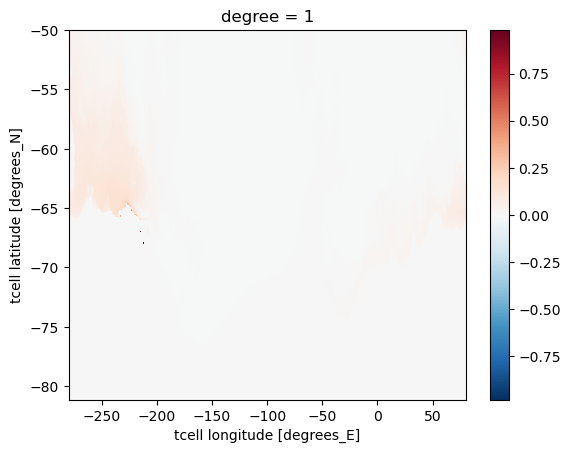

In [22]:
albw_mean_detr.plot()

In [23]:
albw_anom = albw_detr.sel(time=time_slice).groupby('time.month') - albw_clim_weighted
albw_iav_std = albw_anom.groupby('time.year').mean('time').std('year', ddof=1)

rsbw_anom = rsbw_detr.sel(time=time_slice).groupby('time.month') - rsbw_clim_weighted
rsbw_iav_std = rsbw_anom.groupby('time.year').mean('time').std('year', ddof=1)

wsbw_anom = wsbw_detr.sel(time=time_slice).groupby('time.month') - wsbw_clim_weighted
wsbw_iav_std = wsbw_anom.groupby('time.year').mean('time').std('year', ddof=1)

pbbw_anom = pbbw_detr.sel(time=time_slice).groupby('time.month') - pbbw_clim_weighted
pbbw_iav_std = pbbw_anom.groupby('time.year').mean('time').std('year', ddof=1)

In [24]:
albw_iav_std = albw_iav_std.rename('albw_iav_std').to_dataset().assign_attrs(description='Standard deviation of Adélie tracer anomaly (detrended)')
rsbw_iav_std = rsbw_iav_std.rename('rsbw_iav_std').to_dataset().assign_attrs(description='Standard deviation of Ross tracer anomaly (detrended)')
pbbw_iav_std = pbbw_iav_std.rename('pbbw_iav_std').to_dataset().assign_attrs(description='Standard deviation of Prydz tracer anomaly (detrended)')
wsbw_iav_std = wsbw_iav_std.rename('wsbw_iav_std').to_dataset().assign_attrs(description='Standard deviation of Weddell tracer anomaly (detrended)')


In [31]:
rsbw.isel(xt_ocean=1000, yt_ocean=400).plot(label='original', c='#7999D9')
# rsbw_detrend_lnr.isel(xt_ocean=1000, yt_ocean=400).plot(label='detrended', c='#6CD992')
rsbw_detr.isel(xt_ocean=1000, yt_ocean=400).plot(label='detrended (-ax)', c='#C9CBF2')
clim_full = xr.DataArray(
    np.tile(rsbw_clim_weighted.isel(xt_ocean=1000, yt_ocean=400).values, rsbw.isel(xt_ocean=1000, yt_ocean=400).time.size // 12),
    coords={'time': rsbw.isel(xt_ocean=1000, yt_ocean=400).time},
    dims='time'
)
clim_full.plot(label='monthly clim', c='#6CD992')
# rsbw_anom.isel(xt_ocean=1000, yt_ocean=400).plot(label='anomaly')
plt.fill_between(rsbw_detr.time, rsbw_detr.isel(xt_ocean=1000, yt_ocean=400).mean()-rsbw_iav_std['rsbw_iav_std'].isel(xt_ocean=1000, yt_ocean=400), 
                 rsbw_detr.isel(xt_ocean=1000, yt_ocean=400).mean()+rsbw_iav_std['rsbw_iav_std'].isel(xt_ocean=1000, yt_ocean=400), 
                color='#F2F2F2', alpha=0.6, label='2 x std') 
plt.ylabel('Tracer concetration')
plt.xlabel('Time')
plt.ylim(0,0.1)
plt.title('Tracer concentration at a single point')

plt.legend()
plt.savefig('/g/data/x77/ps7863/figures/AABW_variability/4' + '.png', dpi=300)

KeyboardInterrupt: 

In [25]:
# pbbw_iav_std.to_netcdf(f'{savedir}/pbbw_iav_std.nc')
albw_iav_std.to_netcdf(f'{savedir}/albw_iav_std.nc')
# rsbw_iav_std.to_netcdf(f'{savedir}/rsbw_iav_std.nc')
# wsbw_iav_std.to_netcdf(f'{savedir}/wsbw_iav_std.nc')

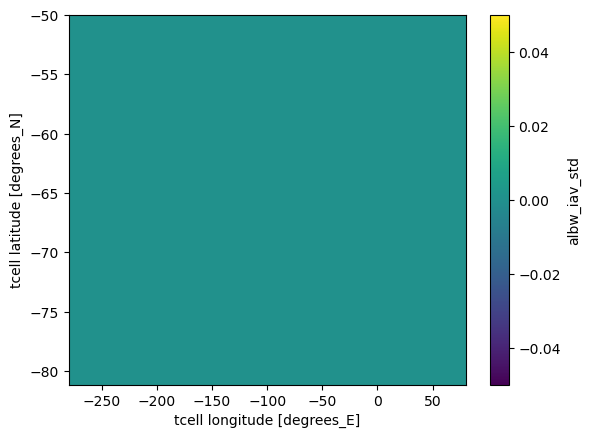

In [24]:
albw_iav_std['albw_iav_std'].plot()

## Transit time

In [6]:
import datetime

In [20]:
albw = xr.open_dataset(f'{savedir}/ALBW_tracer_bottom_500m_01deg_jra55v140_iaf_cycle3_1958-2018.nc')
rsbw = xr.open_dataset(f'{savedir}/RSBW_tracer_bottom_500m_01deg_jra55v140_iaf_cycle3_1958-2018.nc')
wsbw = xr.open_dataset(f'{savedir}/WSBW_tracer_bottom_500m_01deg_jra55v140_iaf_cycle3_1958-2018.nc')
pbbw = xr.open_dataset(f'{savedir}/PBBW_tracer_bottom_500m_01deg_jra55v140_iaf_cycle3_1958-2018.nc')
albw = albw['passive_adelie']
rsbw = rsbw['passive_ross']
wsbw = wsbw['passive_weddell']
pbbw = pbbw['passive_prydz']

In [21]:
# Time-mean before removing the trend

albw_mean = xr.open_dataset(f'{savedir}/albw_circumpolar_mean_1968-2018.nc')
rsbw_mean = xr.open_dataset(f'{savedir}/rsbw_circumpolar_mean_1968-2018.nc')
albw_mean = albw_mean['ALBW mean concentration']
rsbw_mean = rsbw_mean['RSBW mean concentration']

wsbw_mean = xr.open_dataset(f'{savedir}/wsbw_circumpolar_mean_1968-2018.nc')
pbbw_mean = xr.open_dataset(f'{savedir}/pbbw_circumpolar_mean_1968-2018.nc')
wsbw_mean = wsbw_mean['WSBW mean concentration'] 
pbbw_mean = pbbw_mean['PBBW mean concentration']


In [22]:
def annual_mean_from_monthly(var):
    month_length = var.time.dt.days_in_month
    total_days = month_length.sum('time')
    weighted_var = var * month_length / total_days
    weighted_mean = weighted_var.sum('time')
    return weighted_mean 

In [15]:
point = rsbw.isel(yt_ocean=400, xt_ocean=300)

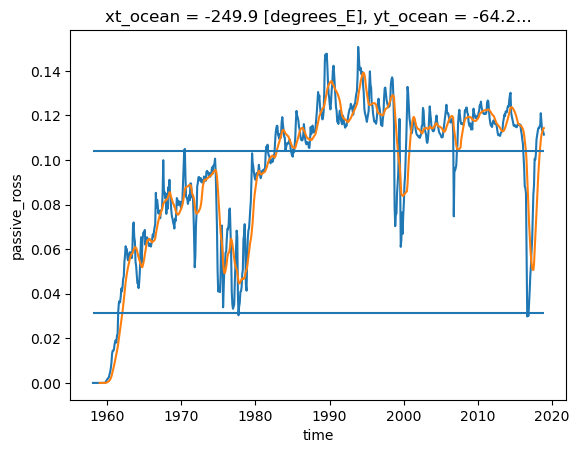

In [23]:
point.plot()
point.rolling(time=12).mean('time').plot()
plt.hlines(point.sel(time=time_slice).mean('time'), xmin=point.time[0], xmax=point.time[-1])
plt.hlines(point.sel(time=time_slice).mean('time')*0.3, xmin=point.time[0], xmax=point.time[-1])


Peak month of SWMT in Weddell and Adélie regions is August, in Ross and Prydz is September.

In [18]:
start_time_weddell = start_time_adelie = np.datetime64('1958-08-16')
start_time_prydz = start_time_ross = np.datetime64('1958-09-16')
pbbw_timedelta = ((pbbw_timing_30 - start_time_prydz).dt.days / 30) # in months


In [10]:
def first_exceedance_timing(da, da_mean, threshold_frac, ref_time, time_source=None, smooth_window=12):
    """
    Find the first time each grid point exceeds a threshold fraction of its mean,
    and return the timing as months elapsed since a reference date.

    Parameters
    ----------
    da : xr.DataArray
        Input tracer with a 'time' dimension.
    da_mean : xr.DataArray or float
        Long-term mean of da (scalar or spatially varying).
    threshold_frac : float
        Fraction of the mean to use as threshold (e.g. 0.30 for 30%).
    ref_time : np.datetime64
        Reference date from which to measure elapsed months.
    time_source : xr.DataArray, optional
        DataArray whose .time coordinate is used for index-to-timestamp mapping.
        Defaults to da itself if None.
    smooth_window : int, optional
        Rolling window size in time steps for smoothing (default 12).

    Returns
    -------
    timing : xr.DataArray
        Months elapsed since ref_time at first exceedance. NaN where no exceedance.
    """
    if time_source is None:
        time_source = da

    # Smooth and threshold
    da_filtered  = da.rolling(time=smooth_window).mean('time')
    condition    = da_filtered >= (da_mean * threshold_frac)
    da_thr       = da.where(condition)

    # Boolean mask: True where original signal passes the threshold
    mask    = ~np.isnan(da_thr)
    has_hit = mask.any("time")

    # Index of first exceedance (argmax returns 0 if no hit, so mask those)
    first_idx = mask.argmax("time")
    first_idx = first_idx.where(has_hit, -1)

    # Map integer indices to timestamps
    times = np.full(first_idx.shape, np.datetime64("NaT"), dtype="datetime64[ns]")
    valid = first_idx.values >= 0
    times[valid] = time_source["time"].values[first_idx.values[valid]]

    # Build output DataArray
    timing_da = xr.DataArray(
        times, coords=first_idx.coords, dims=first_idx.dims
    )

    # Convert to months since reference date
    timedelta = (timing_da - ref_time).dt.days / 30

    return timedelta

In [11]:
start_time_weddell = start_time_adelie = np.datetime64('1958-08-16')
start_time_prydz = start_time_ross = np.datetime64('1958-09-16')

In [23]:
# 30% threshold, using wsbw as the time source (matching your original script)
albw_timing_30 = first_exceedance_timing(
    da             = albw,
    da_mean        = albw_mean,
    threshold_frac = 0.3,
    ref_time       = start_time_adelie,
    time_source    = albw
)

rsbw_timing_30 = first_exceedance_timing(
    da             = rsbw,
    da_mean        = rsbw_mean,
    threshold_frac = 0.3,
    ref_time       = start_time_ross,
    time_source    = rsbw
)
 
pbbw_timing_30 = first_exceedance_timing(
    da             = pbbw,
    da_mean        = pbbw_mean,
    threshold_frac = 0.3,
    ref_time       = start_time_prydz,
    time_source    = pbbw
)

wsbw_timing_30 = first_exceedance_timing(
    da             = wsbw,
    da_mean        = wsbw_mean,
    threshold_frac = 0.3,
    ref_time       = start_time_weddell,
    time_source    = wsbw
)


In [22]:
albw_timing_30.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/albw_filtered_transit_time_30_months.nc')
rsbw_timing_30.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/rsbw_filtered_transit_time_30_months.nc')
pbbw_timing_30.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/wsbw_filtered_transit_time_30_months.nc')
wsbw_timing_30.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/pbbw_filtered_transit_time_30_months.nc')

In [12]:
#15% threshold, using wsbw as the time source (matching your original script)
albw_timing_15 = first_exceedance_timing(
    da             = albw,
    da_mean        = albw_mean,
    threshold_frac = 0.15,
    ref_time       = start_time_adelie,
    time_source    = albw
)

rsbw_timing_15 = first_exceedance_timing(
    da             = rsbw,
    da_mean        = rsbw_mean,
    threshold_frac = 0.15,
    ref_time       = start_time_ross,
    time_source    = rsbw
)

pbbw_timing_15 = first_exceedance_timing(
    da             = pbbw,
    da_mean        = pbbw_mean,
    threshold_frac = 0.15,
    ref_time       = start_time_prydz,
    time_source    = pbbw
)

wsbw_timing_15 = first_exceedance_timing(
    da             = wsbw,
    da_mean        = wsbw_mean,
    threshold_frac = 0.15,
    ref_time       = start_time_weddell,
    time_source    = wsbw
)


In [17]:
albw_timing_15.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/albw_filtered_transit_time_15_months.nc')
rsbw_timing_15.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/rsbw_filtered_transit_time_15_months.nc')
pbbw_timing_15.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/pbbw_filtered_transit_time_15_months.nc')
wsbw_timing_15.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/wsbw_filtered_transit_time_15_months.nc')

In [18]:
#50% threshold, using wsbw as the time source (matching your original script)
albw_timing_50 = first_exceedance_timing(
    da             = albw,
    da_mean        = albw_mean,
    threshold_frac = 0.5,
    ref_time       = start_time_adelie,
    time_source    = albw
)

rsbw_timing_50 = first_exceedance_timing(
    da             = rsbw,
    da_mean        = rsbw_mean,
    threshold_frac = 0.5,
    ref_time       = start_time_ross,
    time_source    = rsbw
)
 
pbbw_timing_50 = first_exceedance_timing(
    da             = pbbw,
    da_mean        = pbbw_mean,
    threshold_frac = 0.5,
    ref_time       = start_time_prydz,
    time_source    = pbbw
)

wsbw_timing_50 = first_exceedance_timing(
    da             = wsbw,
    da_mean        = wsbw_mean,
    threshold_frac = 0.5,
    ref_time       = start_time_weddell,
    time_source    = wsbw
)


In [19]:
albw_timing_50.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/albw_filtered_transit_time_50_months.nc')
rsbw_timing_50.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/rsbw_filtered_transit_time_50_months.nc')
pbbw_timing_50.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/pbbw_filtered_transit_time_50_months.nc')
wsbw_timing_50.to_netcdf('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/circumpolar/wsbw_filtered_transit_time_50_months.nc')

In [26]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cmcrameri
import matplotlib.colors as mcolors


In [27]:
land_50m = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", edgecolor="black", facecolor="grey", linewidth=0.5
)

In [28]:
xt_ocean = ht.xt_ocean
yt_ocean = ht.yt_ocean

NameError: name 'ht' is not defined

In [ ]:
X, Y = np.meshgrid(xt_ocean, yt_ocean)
X = xr.DataArray(X, coords=[yt_ocean, xt_ocean], dims=['yt_ocean', 'xt_ocean'])
Y = xr.DataArray(Y, coords=[yt_ocean, xt_ocean], dims=['yt_ocean', 'xt_ocean'])

In [ ]:
def make_boundary_path(longitudes, latitudes):
    """
    Return a path around boundary to create a sector map, then cut it out given
    longitudes and latitudes.
    """

    boundary_path = np.array([longitudes[-1, :], latitudes[-1, :]])
    boundary_path = np.append(
        boundary_path, np.array([longitudes[::-1, -1], latitudes[::-1, -1]]), axis=1
    )
    boundary_path = np.append(
        boundary_path, np.array([longitudes[1, ::-1], latitudes[1, ::-1]]), axis=1
    )
    boundary_path = np.append(
        boundary_path, np.array([longitudes[:, 1], latitudes[:, 1]]), axis=1
    )
    boundary_path = mpath.Path(np.swapaxes(boundary_path, 0, 1))

    return boundary_path

In [ ]:
# To plot 1000-m contour
contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
shelf = contour_file['contour_masked_above']
yt_ocean = contour_file['yt_ocean']
xt_ocean = contour_file['xt_ocean']
# Mask values that are non-zero
shelf[np.where(shelf!=0)] = np.nan
shelf = shelf+1
shelf = np.nan_to_num(shelf)
shelf = xr.DataArray(shelf, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])

In [ ]:
from matplotlib.colors import ListedColormap

cmap_continuous = cmcrameri.cm.lapaz_r
N=15
colors = cmap_continuous(np.linspace(0, 1, N))

# Create a discrete colormap
lapaz_discrete = ListedColormap(colors, name="lapaz_discrete")

mat = plt.matshow(pbbw_timedelta, cmap=lapaz_discrete, vmin= 1-0.5, 
                      vmax=15+0.5)

In [ ]:
midlon = 0
maxlon = midlon + 80
minlon = midlon - 70
minlat = -80
maxlat = -55
midlat = (minlat + maxlat) / 2

cmap = lapaz_discrete

projection = ccrs.Stereographic(central_longitude=midlon, central_latitude=midlat)

fig = plt.figure(figsize=(12, 6.5))
ax = plt.axes(projection=projection)

ax.add_feature(land_50m)
ax.coastlines(resolution="50m")
ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())


lons = X.sel(
    {"xt_ocean": slice(minlon, maxlon), "yt_ocean": slice(minlat, maxlat)}
)
lats = Y.sel(
    {"xt_ocean": slice(minlon, maxlon), "yt_ocean": slice(minlat, maxlat)}
)

boundary_path = make_boundary_path(lons, lats)
ax.set_boundary(boundary_path, transform=ccrs.PlateCarree())

ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
                [0.5],
                colors = 'k',
                linewidths = 1.5,
                transform=ccrs.PlateCarree())

# ax.contour(ht.xt_ocean, ht.yt_ocean, ht,
#                 levels=[3500],
#                 colors='grey',
#                 linewidths=.8,
#                 alpha=.8,
#                 transform=ccrs.PlateCarree())

norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=7.5, vmax=15)
pc=pbbw_timedelta.plot.pcolormesh(x='xt_ocean', y='yt_ocean', cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
cbar_ax = fig.add_axes([0.3, 0.08, 0.4, 0.02])  # [left, bottom, width, height]
cbar = plt.colorbar(mat, cax=cbar_ax, orientation='horizontal', extend='max') #, ticks=np.arange(14))
# cbar.set_ticklabels(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
cbar.set_label(f'Tracer travel time [yrs]')

plt.suptitle('Time of arrival of 30% of the mean Prydz Bay tracer concentration [from 1958-01-16]')

# plt.savefig(f'{figdir}/pbbw_timing_map_30%_{first_year}-{last_year}.png', dpi=250, bbox_inches='tight')


In [61]:
pbbw_deseason = pbbw.groupby('time.month') -  pbbw.groupby('time.month').mean('time')

pbbw_mean = annual_mean_from_monthly(pbbw_deseason.sel(time=time_slice))
condition = pbbw_deseason >= (pbbw_mean * 0.30)
pbbw_thr_30 = pbbw_deseason.where(condition) 


# True where thresholded field is non-NaN
mask = xr.where(~np.isnan(pbbw_thr_30), True, False)

# Any hit along time?
has_hit = mask.any("time")

# First index of True; returns 0 if none -> we’ll mask those next
first_idx = mask.argmax("time")

# Mark “no hit” locations as -1
first_idx = first_idx.where(has_hit, -1)

# Compute indexer to NumPy (required for vectorised isel)
first_idx_np = first_idx #.compute()

# Map indices to times without indexing -1
times = np.full(first_idx_np.shape, np.datetime64("NaT"), dtype="datetime64[ns]")
valid = first_idx_np.values >= 0
times[valid] = pbbw["time"].values[first_idx_np.values[valid]]

pbbw_timing_30 = xr.DataArray(
    times, coords=first_idx.coords, dims=first_idx.dims, name="pbbw_timing_30"
)

start_time = np.datetime64('1958-01-16')
pbbw_timedelta = ((pbbw_timing_30 - start_time).dt.days / 365) # in years

Text(0.5, 0.98, 'Time of arrival of 30% of the mean Prydz Bay tracer concentration [from 1958-01-16]')

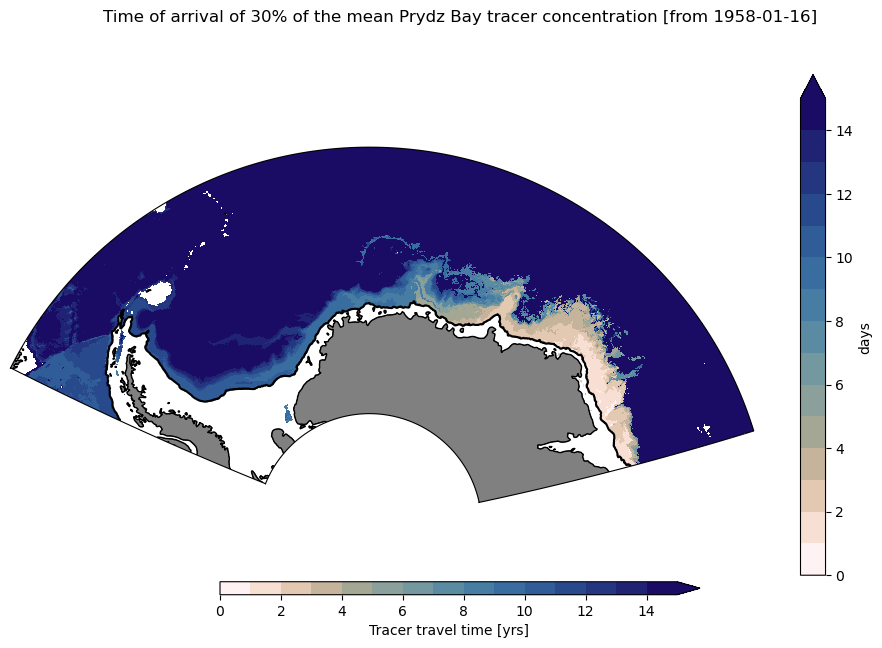

In [62]:
midlon = 0
maxlon = midlon + 80
minlon = midlon - 70
minlat = -80
maxlat = -55
midlat = (minlat + maxlat) / 2

cmap = lapaz_discrete

projection = ccrs.Stereographic(central_longitude=midlon, central_latitude=midlat)

fig = plt.figure(figsize=(12, 6.5))
ax = plt.axes(projection=projection)

ax.add_feature(land_50m)
ax.coastlines(resolution="50m")
ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())


lons = X.sel(
    {"xt_ocean": slice(minlon, maxlon), "yt_ocean": slice(minlat, maxlat)}
)
lats = Y.sel(
    {"xt_ocean": slice(minlon, maxlon), "yt_ocean": slice(minlat, maxlat)}
)

boundary_path = make_boundary_path(lons, lats)
ax.set_boundary(boundary_path, transform=ccrs.PlateCarree())

ax.contour(shelf.xt_ocean, shelf.yt_ocean,shelf,
                [0.5],
                colors = 'k',
                linewidths = 1.5,
                transform=ccrs.PlateCarree())

# ax.contour(ht.xt_ocean, ht.yt_ocean, ht,
#                 levels=[3500],
#                 colors='grey',
#                 linewidths=.8,
#                 alpha=.8,
#                 transform=ccrs.PlateCarree())

norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=7.5, vmax=15)
pc=pbbw_timedelta.plot.pcolormesh(x='xt_ocean', y='yt_ocean', cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
cbar_ax = fig.add_axes([0.3, 0.08, 0.4, 0.02])  # [left, bottom, width, height]
cbar = plt.colorbar(pc, cax=cbar_ax, orientation='horizontal', extend='max') #, ticks=[0,1,2,3,4,5,6,7,8,9,10])
# cbar.set_ticklabels(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])
cbar.set_label(f'Tracer travel time [yrs]')

plt.suptitle('Time of arrival of 30% of the mean Prydz Bay tracer concentration [from 1958-01-16]')

# plt.savefig(f'{figdir}/pbbw_timing_map_30%_{first_year}-{last_year}.png', dpi=250, bbox_inches='tight')


## Temperature and salinity

In [6]:
temp = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/temperature_in_the_bottom_500m_01deg_jra55v140_iaf_cycle3_1968-2018.nc')
salt = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/salinity_in_the_bottom_500m_01deg_jra55v140_iaf_cycle3_1968-2018.nc')
salt_abs = xr.open_dataset('/g/data/x77/ps7863/data/AABW_variability/bottom_500m/absolute_salinity_in_the_bottom_500m_01deg_jra55v140_iaf_cycle3_1958-2018.nc')
temp = temp['temp']
salt = salt['salt']
salt_abs = salt_abs['salt']

In [7]:
temp

<xarray.DataArray 'temp' (time: 612, yt_ocean: 666, xt_ocean: 3600)> Size: 12GB
[1467331200 values with dtype=float64]
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 5kB -81.11 -81.07 -81.02 ... -50.09 -50.03
  * time      (time) datetime64[ns] 5kB 1968-01-16T12:00:00 ... 2018-12-16T12...

In [8]:
temp = temp.sel(time=time_slice)
salt = salt.sel(time=time_slice)
salt_abs = salt_abs.sel(time=time_slice)

In [10]:
temp_detr = detrend_keep_mean(temp)
salt_detr = detrend_keep_mean(salt)
salt_abs_detr = detrend_keep_mean(salt_abs)

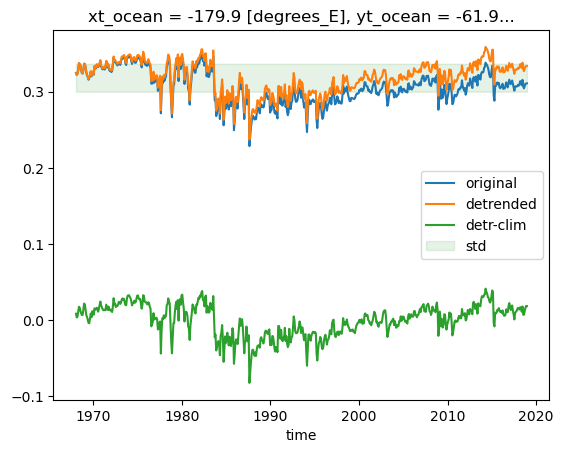

In [22]:
temp.isel(xt_ocean=1000, yt_ocean=450).plot(label='original')
temp_detr.isel(xt_ocean=1000, yt_ocean=450).plot(label='detrended')
temp_anom.isel(xt_ocean=1000, yt_ocean=450).plot(label='detr-clim')
plt.fill_between(temp.time, temp_detr.isel(xt_ocean=1000, yt_ocean=450).mean('time')-temp_iav_std.isel(xt_ocean=1000, yt_ocean=450), 
                temp_detr.isel(xt_ocean=1000, yt_ocean=450).mean('time')+temp_iav_std.isel(xt_ocean=1000, yt_ocean=450),
                 alpha=0.1, 
                 color='green', 
                 label='std'
                )
plt.legend()
# plt.fill_between(temp.time, temp_detr.isel(xt_ocean=1000, yt_ocean=450).mean('time')-temp_detr.isel(xt_ocean=1000, yt_ocean=450).std(dim='time'), 
#                 temp_detr.isel(xt_ocean=1000, yt_ocean=450).mean('time')+temp_detr.isel(xt_ocean=1000, yt_ocean=450).std(dim='time'), alpha=0.1,color='red')

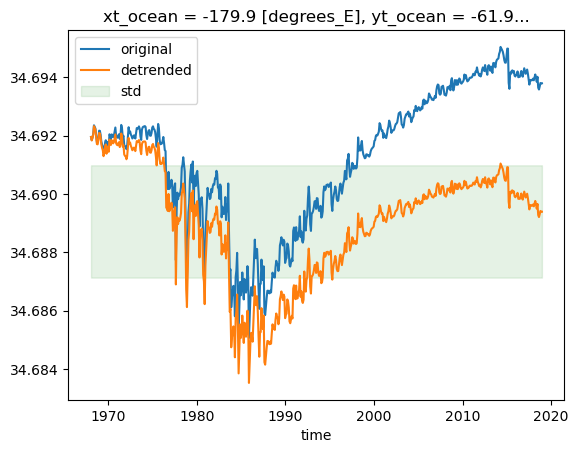

In [24]:
salt.isel(xt_ocean=1000, yt_ocean=450).plot(label='original')
salt_detr.isel(xt_ocean=1000, yt_ocean=450).plot(label='detrended')
# salt_anom.isel(xt_ocean=1000, yt_ocean=450).plot(label='detr-clim')
plt.fill_between(salt.time, salt_detr.isel(xt_ocean=1000, yt_ocean=450).mean('time')-salt_iav_std.isel(xt_ocean=1000, yt_ocean=450), 
                salt_detr.isel(xt_ocean=1000, yt_ocean=450).mean('time')+salt_iav_std.isel(xt_ocean=1000, yt_ocean=450),
                 alpha=0.1, 
                 color='green', 
                 label='std'
                )
plt.legend()
# plt.fill_between(temp.time, temp_detr.isel(xt_ocean=1000, yt_ocean=450).mean('time')-temp_detr.isel(xt_ocean=1000, yt_ocean=450).std(dim='time'), 
#                 temp_detr.isel(xt_ocean=1000, yt_ocean=450).mean('time')+temp_detr.isel(xt_ocean=1000, yt_ocean=450).std(dim='time'), alpha=0.1,color='red')

In [16]:

w = xr.DataArray(temp.sel(time=time_slice)['time'].dt.days_in_month,
                 coords={'time': temp.sel(time=time_slice)['time']}, dims='time')
temp_clim_weighted = groupby_weighted_mean(temp_detr, 'time.month', w)
salt_clim_weighted = groupby_weighted_mean(salt_detr, 'time.month', w)
salt_abs_clim_weighted = groupby_weighted_mean(salt_abs_detr,'time.month', w)

temp_range = temp_clim_weighted.max('month') - temp_clim_weighted.min('month')
salt_range = salt_clim_weighted.max('month') - salt_clim_weighted.min('month')
salt_abs_range = salt_abs_clim_weighted.max('month') - salt_abs_clim_weighted.min('month')

In [13]:
temp_anom = temp_detr.sel(time=time_slice).groupby('time.month') - temp_clim_weighted
temp_iav_std = temp_anom.groupby('time.year').mean('time').std('year', ddof=1)

salt_anom = salt_detr.sel(time=time_slice).groupby('time.month') - salt_clim_weighted
salt_iav_std = salt_anom.groupby('time.year').mean('time').std('year', ddof=1)

salt_abs_anom = salt_abs_detr.sel(time=time_slice).groupby('time.month') - salt_abs_clim_weighted
salt_abs_iav_std = salt_abs_anom.groupby('time.year').mean('time').std('year', ddof=1)

In [15]:
temp_iav_std = temp_iav_std.rename('temp_iav_std').to_dataset().assign_attrs(description='Standard deviation of temperature (CT) (detrended)')
# salt_iav_std = salt_iav_std.rename('salt_iav_std').to_dataset().assign_attrs(description='Standard deviation of temperature (practical) (detrended)')

In [16]:
temp_iav_std.to_netcdf(f'{savedir}/temp_std.nc')
# salt_iav_std.to_netcdf(f'{savedir}/salt_std.nc')

In [14]:
salt_abs_iav_std = salt_abs_iav_std.rename('salt_abs_std').to_dataset().assign_attrs(description='Standard deviation of absolute salinity (detrended)')
salt_abs_iav_std.to_netcdf(f'{savedir}/salt_abs_std.nc')


In [17]:
salt_abs_range = salt_abs_range.rename('salt_abs_range').to_dataset().assign_attrs(description='Seasonal range of absolute salinity (detrended), 1968–2018')
temp_range = temp_range.rename('temp_range').to_dataset().assign_attrs(description='Seasonal range of conservative temperature (detrended), 1968–2018')

In [19]:
salt_abs_range.to_netcdf(f'{savedir}/Seasonal_range_of_SA_{iaf_cycle3}_{first_year}-{last_year}.nc')
temp_range.to_netcdf(f'{savedir}/Seasonal_range_of_CT_{iaf_cycle3}_{first_year}-{last_year}.nc')

In [20]:
savedir

'/g/data/x77/ps7863/data/AABW_variability/bottom_500m/'